# World Cup 2026 Match Predictor

A Poisson goal model that predicts win/draw/loss probabilities and expected goals for any World Cup 2026 matchup, built from completed match data.

**Approach:** Each team gets a smoothed attack and defence rating based on goals scored/conceded so far in the tournament. These ratings combine to produce an expected goals (lambda) value for any matchup, which feeds a Poisson distribution to generate scoreline probabilities and match outcome odds.

**Data source:** [openfootball/worldcup.json](https://github.com/openfootball/worldcup.json) — live tournament data, re-fetched each run.


## Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson
import warnings
import sys
sys.path.append('../src')

from data_loader import load_matches
from poisson_model import compute_ratings, predict_match, scoreline_matrix
from visualiser import plot_scoreline_heatmap, plot_predictions_summary

warnings.filterwarnings('ignore')

In [3]:
URL = "https://raw.githubusercontent.com/openfootball/worldcup.json/master/2026/worldcup.json"
df = load_matches(URL)
df['goal_total'] = df['goal1'] + df['goal2']
print(df.shape)
df.head()

(104, 8)


,round,date,team1,team2,group,goal1,goal2,goal_total
0,Matchday 1,2026-06-11,Mexico,South Africa,Group A,2,0,2
1,Matchday 1,2026-06-11,South Korea,Czech Republic,Group A,2,1,3
2,Matchday 8,2026-06-18,Czech Republic,South Africa,Group A,1,1,2
3,Matchday 8,2026-06-18,Mexico,South Korea,Group A,1,0,1
4,Matchday 14,2026-06-24,Czech Republic,Mexico,Group A,0,3,3


`load_matches()` returns only *completed* matches, needed for building ratings. Predicting upcoming fixtures (below) needs the raw match list too, since unplayed matches have no score yet.

In [4]:
import requests
raw = requests.get(URL).json()
all_matches = raw['matches']

## Exploratory Data Analysis

Before modelling, a quick look at scoring patterns across the tournament so far.

### Average goals per match, by group

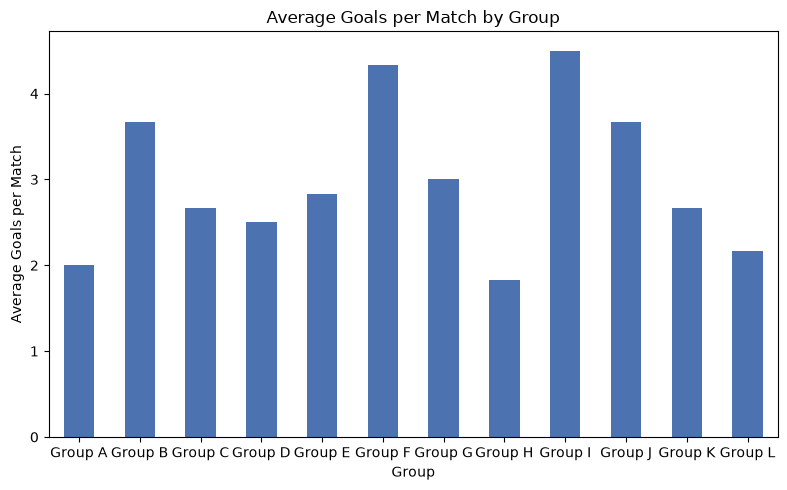

In [5]:
group_stage = df[df['group'].notna()]
avg_goals_by_group = group_stage.groupby('group')['goal_total'].mean()

plt.figure(figsize=(8, 5))
avg_goals_by_group.plot(kind='bar', color='#4C72B0')
plt.xlabel('Group')
plt.ylabel('Average Goals per Match')
plt.title('Average Goals per Match by Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Top 10 highest-scoring teams

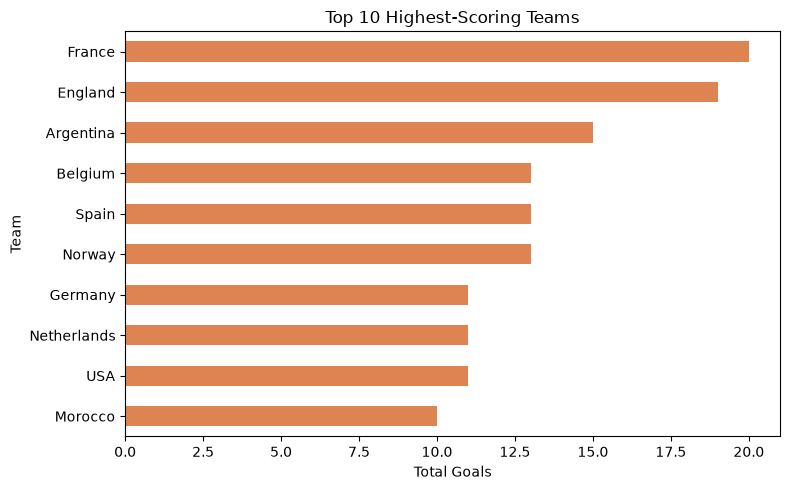

In [6]:
team1_goals = df[['team1', 'goal1']].rename(columns={'team1': 'team', 'goal1': 'goals'})
team2_goals = df[['team2', 'goal2']].rename(columns={'team2': 'team', 'goal2': 'goals'})
all_goals = pd.concat([team1_goals, team2_goals])

total_goals_by_team = all_goals.groupby('team')['goals'].sum()
top10 = total_goals_by_team.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10.plot(kind='barh', color='#DD8452')
plt.xlabel('Total Goals')
plt.ylabel('Team')
plt.title('Top 10 Highest-Scoring Teams')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model: Ratings Table

`compute_ratings()` builds a smoothed attack/defence rating for every team using all completed matches, with a smoothing factor (k=3) to prevent zero-rated defences on small samples.

In [7]:
ratings_df = compute_ratings(df)
avg_goals = df['goal_total'].mean()
ratings_df.head()

,team,attack,defence
0,Mexico,0.563333,0.260000
1,South Korea,0.288889,0.346667
2,Czech Republic,0.288889,0.520000
3,South Africa,0.247619,0.346667
4,Canada,0.520000,0.390000


Predicting a single matchup:

In [8]:
result = predict_match('Brazil', 'Argentina', ratings_df, avg_goals)
result
r = result
print(f"{r['team1']} vs {r['team2']}\n")
print(f"{r['team1']} Win: {r['prob_team1_win']:.0%}")
print(f"Draw: {r['prob_draw']:.0%}")
print(f"{r['team2']} Win: {r['prob_team2_win']:.0%}")

Brazil vs Argentina

Brazil Win: 25%
Draw: 48%
Argentina Win: 27%


## Predictions: Semi-final

Predictions generated for the Semi-final round, the live round at the time this notebook was run.

In [9]:
upcoming = [m for m in all_matches if m.get('score') is None and m['round'] == 'Final']

rows = []
for m in upcoming:
    result = predict_match(m['team1'], m['team2'], ratings_df, avg_goals)
    rows.append(result)

predictions_df = pd.DataFrame(rows)
predictions_df['predicted_winner'] = predictions_df.apply(
    lambda row: (
        row['team1'] if row['prob_team1_win'] >= row['prob_team2_win']
        else row['team2']
    ),
    axis=1
)
predictions_df

ValueError: Cannot set a DataFrame without columns to the column predicted_winner

**Note on knockout predictions:** draws go to extra time/penalties, which the model doesn't predict. For knockout matches, the predicted winner is simply the team with the higher win probability.

## Visualisations

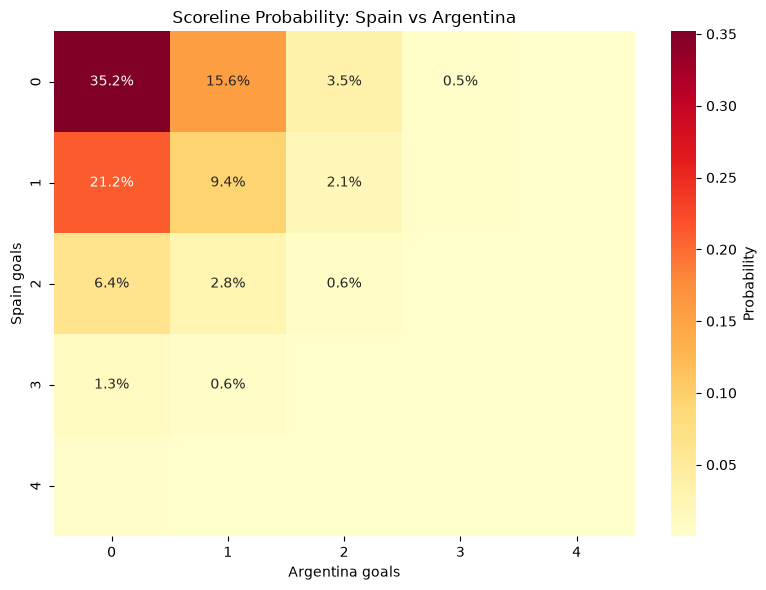

In [ ]:
result = predict_match('Spain', 'Argentina', ratings_df, avg_goals)
matrix = scoreline_matrix(result['lambda1'], result['lambda2'])
plot_scoreline_heatmap(matrix, 'Spain', 'Argentina')

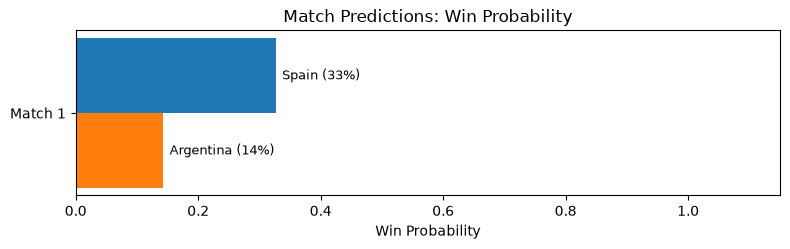

In [ ]:
plot_predictions_summary(predictions_df)

## Limitations & Future Work

- **Small sample size**: with only a handful of matches per team, ratings can end up identical for teams with similar early results (e.g. Brazil and Argentina early in the tournament).
- **Low lambda / draw-heavy predictions**: expected goals values are modest, which pushes draw probability up. For knockout rounds, this is handled by ignoring draw probability and picking the team with the higher win probability, since draws can't go to the scoreboard in single-elimination football.
- **Smoothing factor (k=3)**: chosen to be smaller than the typical k=5 used for full league seasons, since the World Cup gives each team far fewer matches to establish a rating from.
- **No first-goalscorer prediction**: individual scorer data (name, minute) is available in the source JSON but excluded from this model, since the Poisson approach only needs aggregate goals. Noted as potential future work.
- **Independence assumption**: the model assumes each team's goals are statistically independent of the opponent's, which is a simplification — real matches have tactical interplay between both sides.
